# Bước 1: Khám phá Dữ liệu (Exploratory Data Analysis - EDA)

Mục tiêu của bước này là hiểu rõ cấu trúc dữ liệu, tìm ra các mối tương quan quan trọng và các đặc trưng (features) ảnh hưởng mạnh nhất đến việc khách hàng rời bỏ dịch vụ (`Attrition_Flag`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết biểu đồ cho đẹp
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Load dữ liệu
df = pd.read_csv('../data/BankChurners.csv')

# 2. Loại bỏ các cột không cần thiết theo yêu cầu của dataset (2 cột Naive Bayes cuối và CLIENTNUM)
# Các cột này đã được tác giả dataset trên Kaggle khuyên nên loại bỏ vì nó là kết quả của mô hình cũ.
cols_to_drop = [col for col in df.columns if col.startswith('Naive_Bayes')] + ['CLIENTNUM']
df = df.drop(columns=cols_to_drop)

print(f"Cấu trúc dữ liệu sau khi làm sạch sơ bộ: {df.shape}")
df.head()

Cấu trúc dữ liệu sau khi làm sạch sơ bộ: (10127, 20)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## 1. Phân tích biến mục tiêu (Target Variable)

Kiểm tra xem dữ liệu có bị mất cân bằng (Imbalance) không.

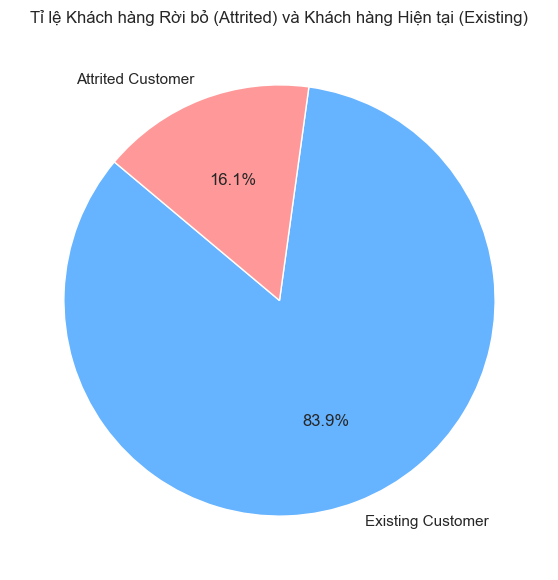

Số lượng khách hàng mỗi nhóm:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


In [2]:
attrition_counts = df['Attrition_Flag'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Tỉ lệ Khách hàng Rời bỏ (Attrited) và Khách hàng Hiện tại (Existing)')
plt.show()

print("Số lượng khách hàng mỗi nhóm:")
print(attrition_counts)

**Nhận xét:** Dữ liệu có sự mất cân bằng khá lớn (16.1% rời bỏ). Khi huấn luyện mô hình phân lớp, cần chú trọng vào metric F1-Score hoặc Recall thay vì chỉ nhìn vào Accuracy.

## 2. Phân tích các đặc điểm Nhân khẩu học

Chúng ta xem xét các yếu tố như Độ tuổi, Giới tính, Thu nhập ảnh hưởng thế nào đến Churn.

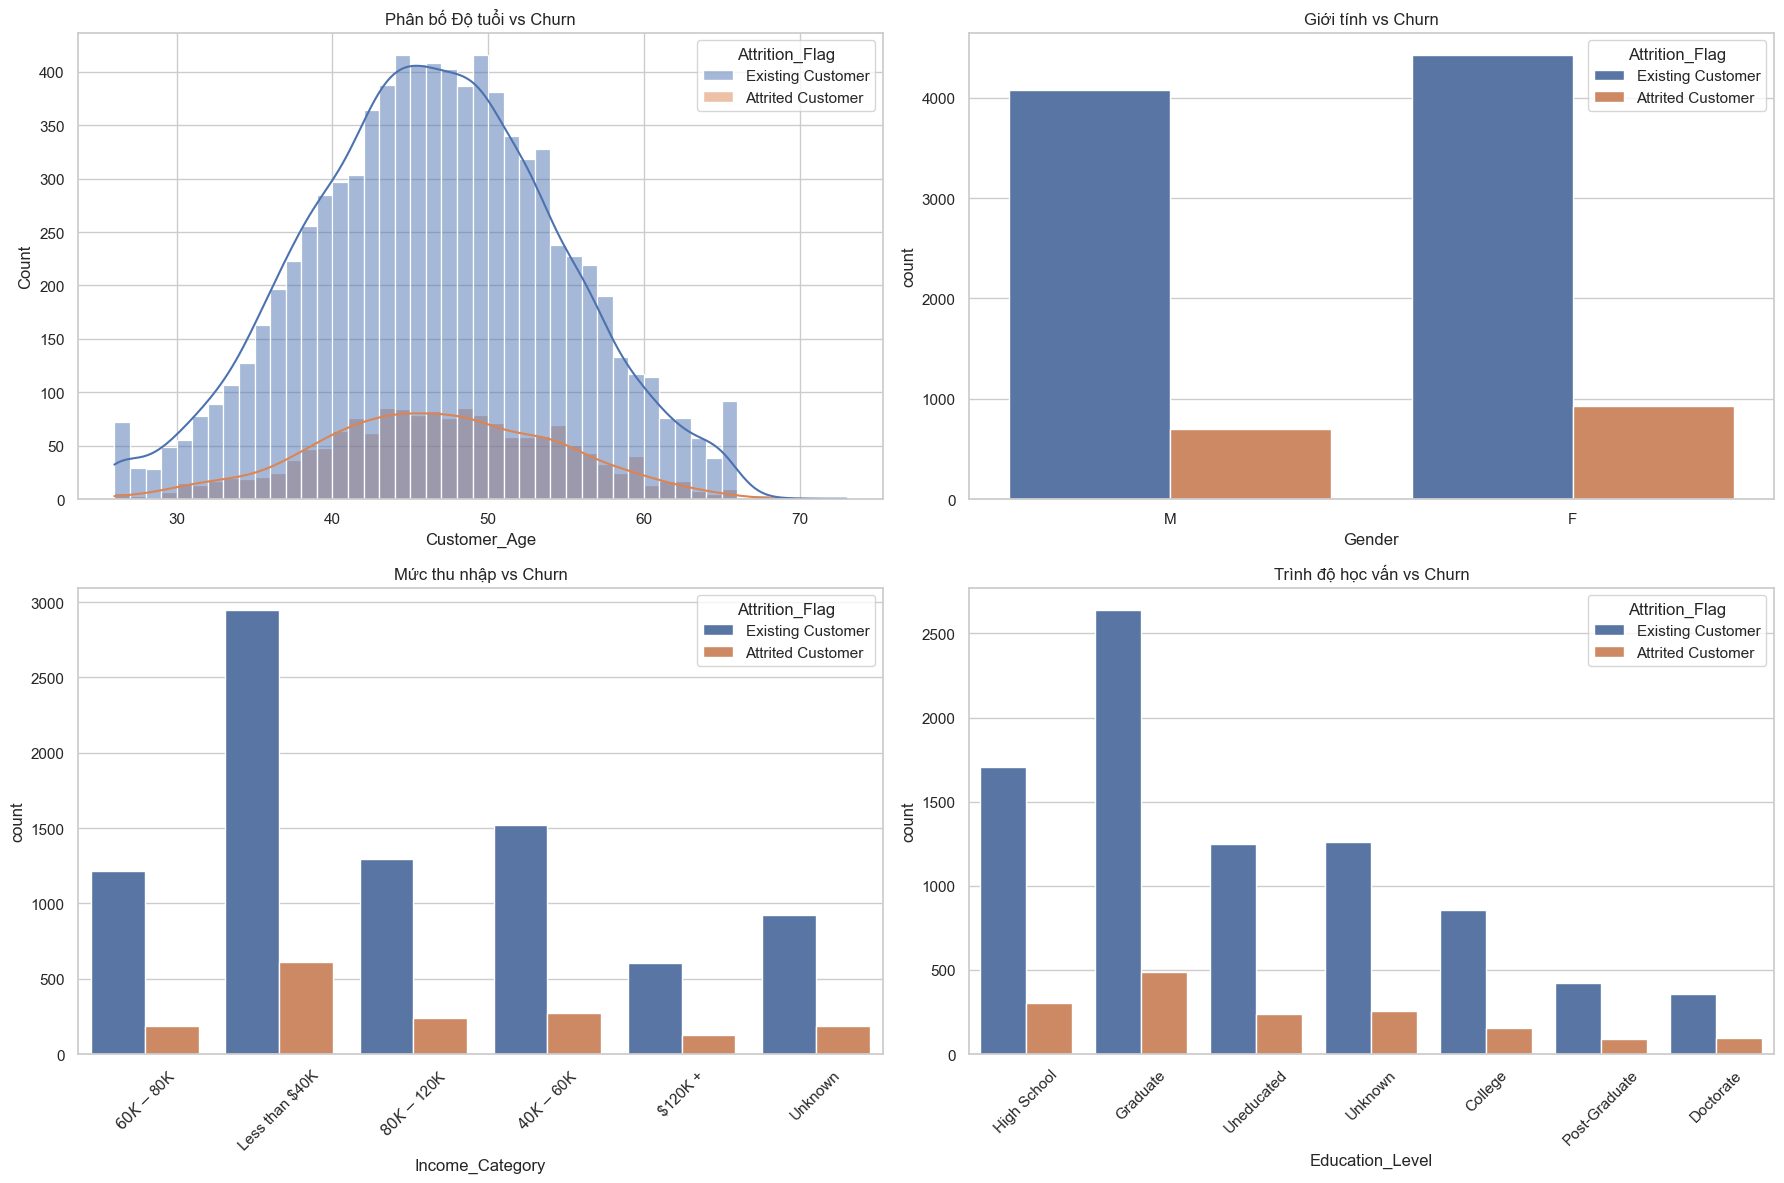

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Phân bố độ tuổi
sns.histplot(data=df, x='Customer_Age', hue='Attrition_Flag', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Phân bố Độ tuổi vs Churn')

# Churn theo giới tính
sns.countplot(data=df, x='Gender', hue='Attrition_Flag', ax=axes[0, 1])
axes[0, 1].set_title('Giới tính vs Churn')

# Churn theo thu nhập
sns.countplot(data=df, x='Income_Category', hue='Attrition_Flag', ax=axes[1, 0])
axes[1, 0].set_title('Mức thu nhập vs Churn')
plt.setp(axes[1, 0].get_xticklabels(), rotation=45)

# Churn theo trình độ học vấn
sns.countplot(data=df, x='Education_Level', hue='Attrition_Flag', ax=axes[1, 1])
axes[1, 1].set_title('Trình độ học vấn vs Churn')
plt.setp(axes[1, 1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 3. Phân tích Hành vi Giao dịch (Quan trọng nhất)

Đây thường là các đặc trưng có khả năng dự đoán cao nhất.

C:\Users\23110\AppData\Local\Temp\ipykernel_29564\1630088085.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y=feature, ax=axes[i], palette='Set2')
C:\Users\23110\AppData\Local\Temp\ipykernel_29564\1630088085.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y=feature, ax=axes[i], palette='Set2')
C:\Users\23110\AppData\Local\Temp\ipykernel_29564\1630088085.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y=feature, ax=axes[i], palette='Set2')
C:\U

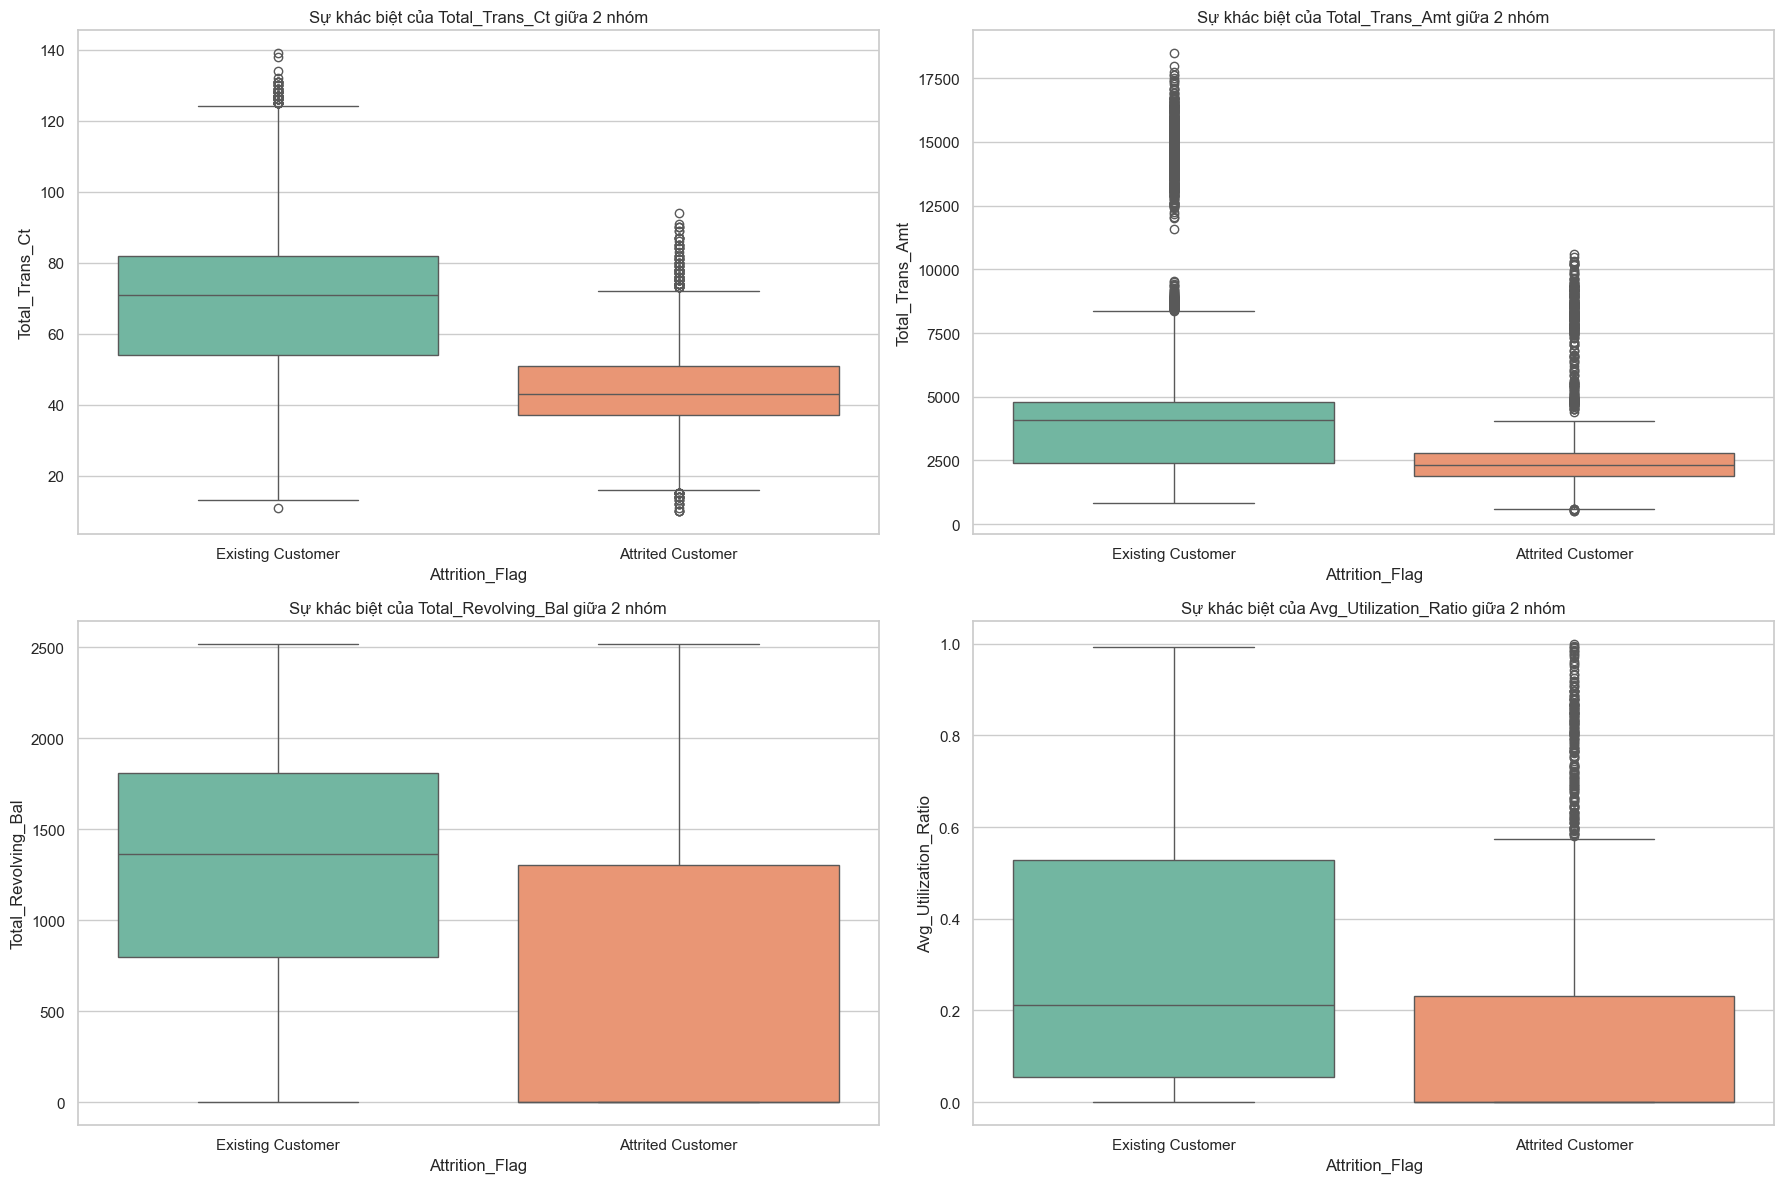

In [4]:
transaction_features = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(transaction_features):
    sns.boxplot(data=df, x='Attrition_Flag', y=feature, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Sự khác biệt của {feature} giữa 2 nhóm')

plt.tight_layout()
plt.show()

**Nhận xét:**
- Khách hàng rời bỏ (`Attrited`) có **số lượng giao dịch (Total_Trans_Ct)** thấp hơn hẳn nhóm ở lại.
- Nhóm rời bỏ có **số dư xoay vòng (Total_Revolving_Bal)** thấp hơn, cho thấy họ ít sử dụng thẻ làm công cụ vay mượn chính.

## 4. Ma trận Tương quan (Correlation Matrix)

Xem xét mối quan hệ tuyến tính giữa các biến số.

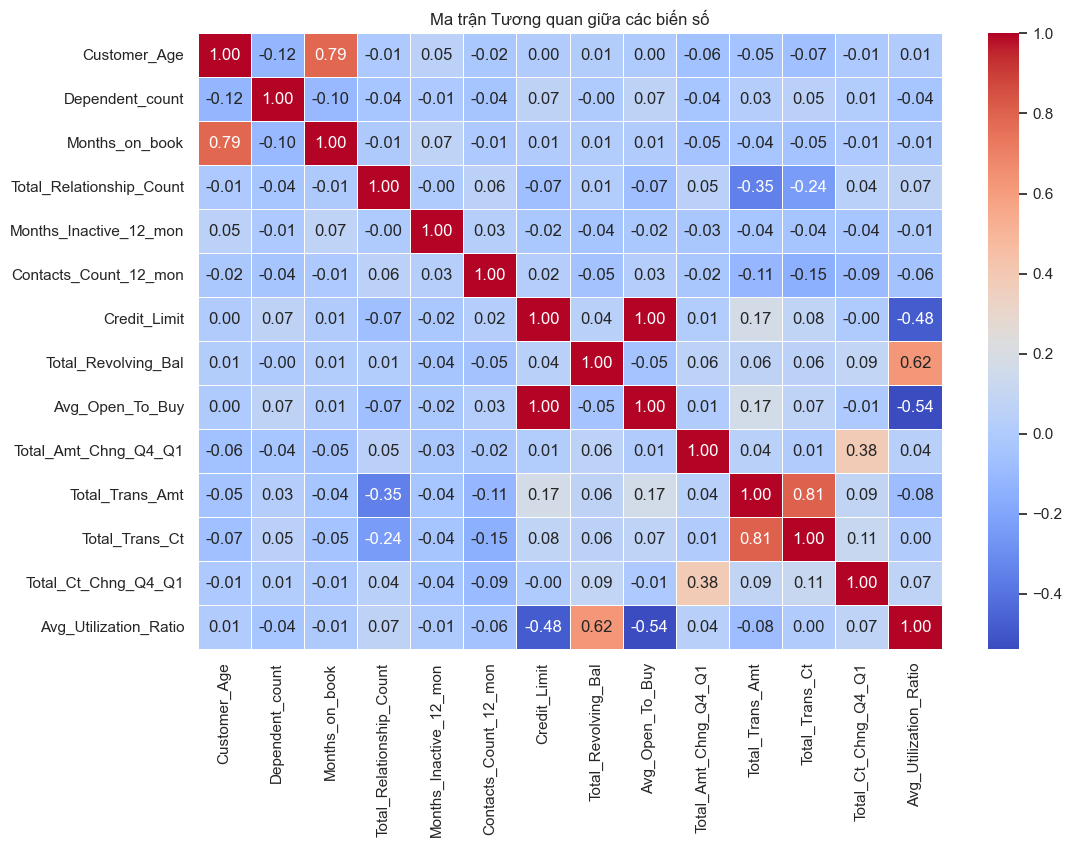

In [5]:
# Chỉ lấy các cột numeric
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận Tương quan giữa các biến số')
plt.show()

**Nhận xét:**
- `Total_Trans_Ct` và `Total_Trans_Amt` có tương quan cực kỳ mạnh (0.81), điều này dễ hiểu vì giao dịch nhiều thì tổng tiền thường lớn. Tuy nhiên có thể gây hiện tượng đa cộng tuyến (multicollinearity).
- `Credit_Limit` và `Avg_Open_To_Buy` có tương quan gần như tuyệt đối (0.996). Ta có thể cân nhắc loại bỏ 1 trong 2 để giảm nhiễu.